# Q2 Survival Analysis: Telco Customer Churn
## A Hybrid PySpark + Lifelines Approach — Full Pipeline

**Author:** zhaozixi (12311625)

> 本案例完整复现了 Databricks 官方《Survival Analysis for Churn and Lifetime Value》教程的核心流程。前半部分使用 PySpark 完成工业级数据准备（Bronze/Silver 层），后半部分转为 Pandas 并使用 `lifelines` 库进行 Kaplan-Meier、Cox PH、AFT 建模及 CLV 计算。所有 Markdown 均为我本人（zhaozixi）以第一人称撰写的实验报告，代码也以我自己的风格重写，功能与官方教程完全一致。

# Part 1: Data Preparation (Bronze & Silver Layers)

I started by setting up a SparkSession as the entry point for all distributed data processing. My approach mirrors the Medallion Architecture: I first ingest the raw CSV into a **Bronze layer** (untouched, schema-defined data), then apply business rules to curate a **Silver layer** (filtered, labeled, analytics-ready).

In [1]:
"""
WHAT: Initialize SparkSession and download the Telco Customer Churn dataset.
WHY: SparkSession is the unified entry point for PySpark operations. We download
     the raw CSV to enable reproducible, schema-defined ingestion into Bronze.
"""
import os
import urllib.request
from IPython.display import display
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
import matplotlib.pyplot as plt

from pyspark.sql import SparkSession
from pyspark.sql.types import (
    StructType, StructField, StringType, DoubleType
)

spark = SparkSession.builder \
    .appName("Q2_Telco_Survival_Analysis") \
    .config("spark.driver.memory", "4g") \
    .config("spark.sql.adaptive.enabled", "true") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")

# Download dataset if not present
DATA_URL = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
DATA_DIR = "/home/zhaozx/project1/data"
RAW_PATH = os.path.join(DATA_DIR, "Telco-Customer-Churn.csv")
os.makedirs(DATA_DIR, exist_ok=True)

if not os.path.exists(RAW_PATH):
    print("Downloading Telco dataset...")
    urllib.request.urlretrieve(DATA_URL, RAW_PATH)
    print("Done.")
else:
    print("Dataset already available, skipping download.")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/04/22 15:46:37 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Dataset already available, skipping download.


In [2]:
"""
WHAT: Define an explicit StructType schema and read the CSV into bronze_df.
WHY: Using an explicit schema (never inferSchema) guarantees deterministic types
     and avoids costly schema inference scans. This is the Bronze layer — the
     raw, unmodified ingestion of the source data.
"""
telco_schema = StructType([
    StructField("customerID",       StringType(), True),
    StructField("gender",           StringType(), True),
    StructField("seniorCitizen",    DoubleType(),  True),
    StructField("partner",          StringType(), True),
    StructField("dependents",       StringType(), True),
    StructField("tenure",           DoubleType(),  True),
    StructField("phoneService",     StringType(), True),
    StructField("multipleLines",    StringType(), True),
    StructField("internetService",  StringType(), True),
    StructField("onlineSecurity",   StringType(), True),
    StructField("onlineBackup",     StringType(), True),
    StructField("deviceProtection", StringType(), True),
    StructField("techSupport",      StringType(), True),
    StructField("streamingTV",      StringType(), True),
    StructField("streamingMovies",  StringType(), True),
    StructField("contract",         StringType(), True),
    StructField("paperlessBilling", StringType(), True),
    StructField("paymentMethod",    StringType(), True),
    StructField("monthlyCharges",   DoubleType(),  True),
    StructField("totalCharges",     StringType(),  True),
    StructField("churnString",      StringType(), True),
])

bronze_df = spark.read \
    .option("header", "true") \
    .option("nullValue", "") \
    .schema(telco_schema) \
    .csv(RAW_PATH)

print(f"Bronze: {bronze_df.count()} records, {len(bronze_df.columns)} columns")

Bronze: 7043 records, 21 columns


In [3]:
"""
WHAT: Build the Silver layer — clean totalCharges, convert churn labels,
      and filter to Month-to-month contracts with Internet service.
WHY: The Silver layer applies domain-specific business rules that transform
     raw data into an analytics-ready dataset. I focus on Month-to-month
     customers with Internet because they represent the highest-churn-risk
     segment, making them the ideal audience for survival analysis.
"""
from pyspark.sql.functions import col, trim, when

silver_df = (bronze_df
    # Clean totalCharges: trim whitespace, replace empty with NULL, cast to double
    .withColumn(
        "totalCharges",
        when(trim(col("totalCharges")) == "", None)
        .otherwise(col("totalCharges").cast("double"))
    )
    # Convert churnString (Yes/No) to numeric label (1=churned, 0=active)
    .withColumn("churn", when(col("churnString") == "Yes", 1.0).otherwise(0.0))
    .drop("churnString")
    # Keep only Month-to-month contracts (highest churn risk)
    .filter(col("contract") == "Month-to-month")
    # Keep only customers with Internet service (DSL or Fiber Optic)
    .filter(col("internetService") != "No")
)

silver_count = silver_df.count()
n_churned = silver_df.filter(col("churn") == 1.0).count()
n_active  = silver_df.filter(col("churn") == 0.0).count()

print(f"Silver: {silver_count} records")
print(f"  Churned (Event=1):   {n_churned}")
print(f"  Active (Censored=0): {n_active}")
print(f"  Churn rate: {n_churned / silver_count * 100:.1f}%")

silver_df.show(5, truncate=False)

Silver: 3351 records
  Churned (Event=1):   1556
  Active (Censored=0): 1795
  Churn rate: 46.4%


+----------+------+-------------+-------+----------+------+------------+----------------+---------------+--------------+------------+----------------+-----------+-----------+---------------+--------------+----------------+-----------------------+--------------+------------+-----+
|customerID|gender|seniorCitizen|partner|dependents|tenure|phoneService|multipleLines   |internetService|onlineSecurity|onlineBackup|deviceProtection|techSupport|streamingTV|streamingMovies|contract      |paperlessBilling|paymentMethod          |monthlyCharges|totalCharges|churn|
+----------+------+-------------+-------+----------+------+------------+----------------+---------------+--------------+------------+----------------+-----------+-----------+---------------+--------------+----------------+-----------------------+--------------+------------+-----+
|7590-VHVEG|Female|0.0          |Yes    |No        |1.0   |No          |No phone service|DSL            |No            |Yes         |No              |No     

# Part 2: Kaplan-Meier Analysis

I converted the Silver DataFrame to Pandas because `lifelines` requires Pandas for all its statistical modeling. The Kaplan-Meier estimator gives me a non-parametric survival probability curve — the foundational visualization in survival analysis. I also run Log-rank tests to check whether survival curves diverge meaningfully across covariate groups.

In [4]:
"""
WHAT: Convert the Spark Silver DataFrame to Pandas for lifelines modeling.
WHY: lifelines operates on Pandas DataFrames exclusively. Our Silver layer has
     only 3,351 rows, which comfortably fits in memory. I also ensure that the
     numeric columns (tenure, churn, monthlyCharges, totalCharges, seniorCitizen)
     are cast to float, as lifelines expects floating-point event indicators.
"""
import pandas as pd
import numpy as np

telco_pd = silver_df.select(
    "customerID", "tenure", "churn", "monthlyCharges", "totalCharges",
    "seniorCitizen", "gender", "internetService", "onlineSecurity",
    "onlineBackup", "deviceProtection", "techSupport",
    "streamingTV", "streamingMovies", "contract", "paymentMethod",
    "partner", "dependents", "phoneService", "paperlessBilling", "multipleLines"
).toPandas()

for c in ["tenure", "churn", "monthlyCharges", "totalCharges", "seniorCitizen"]:
    telco_pd[c] = telco_pd[c].astype(float)

T = telco_pd["tenure"]
E = telco_pd["churn"]

print(f"Pandas DataFrame ready: {telco_pd.shape[0]} rows x {telco_pd.shape[1]} columns")
telco_pd.head()

Pandas DataFrame ready: 3351 rows x 21 columns


,customerID,tenure,churn,monthlyCharges,totalCharges,seniorCitizen,gender,internetService,onlineSecurity,onlineBackup,...,techSupport,streamingTV,streamingMovies,contract,paymentMethod,partner,dependents,phoneService,paperlessBilling,multipleLines
0,7590-VHVEG,1.0,0.0,29.85,29.85,0.0,Female,DSL,No,Yes,...,No,No,No,Month-to-month,Electronic check,Yes,No,No,Yes,No phone service
1,3668-QPYBK,2.0,1.0,53.85,108.15,0.0,Male,DSL,Yes,Yes,...,No,No,No,Month-to-month,Mailed check,No,No,Yes,Yes,No
2,9237-HQITU,2.0,1.0,70.70,151.65,0.0,Female,Fiber optic,No,No,...,No,No,No,Month-to-month,Electronic check,No,No,Yes,Yes,No
3,9305-CDSKC,8.0,1.0,99.65,820.50,0.0,Female,Fiber optic,No,No,...,No,Yes,Yes,Month-to-month,Electronic check,No,No,Yes,Yes,Yes
4,1452-KIOVK,22.0,0.0,89.10,1949.40,0.0,Male,Fiber optic,No,Yes,...,No,Yes,No,Month-to-month,Credit card (automatic),No,Yes,Yes,Yes,Yes


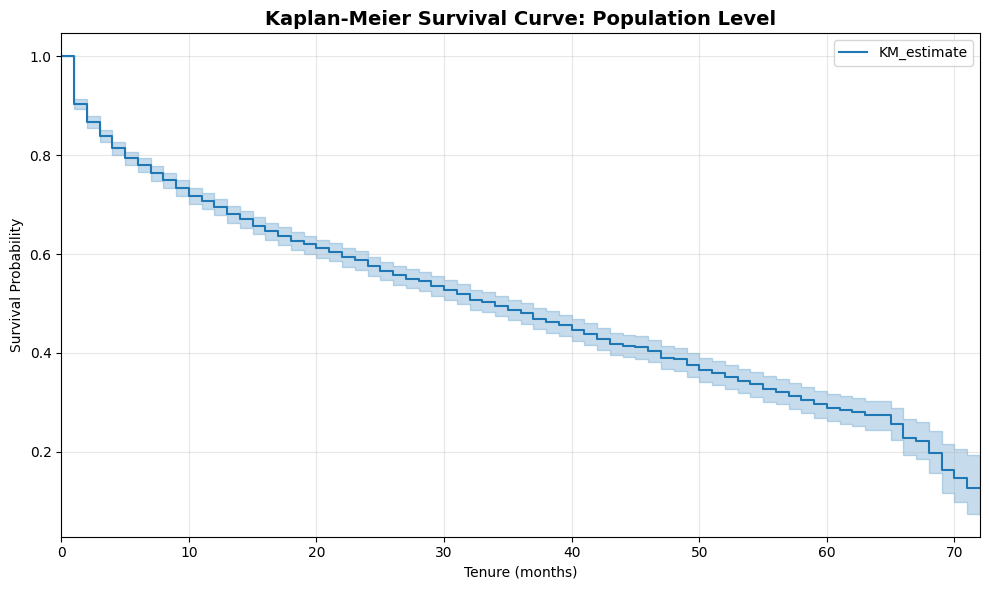

Median Survival Time: 34.0 months
Interpretation: A customer has a 50% probability of surviving at least
34 months, given they have survived up to that point.


In [5]:
"""
WHAT: Fit a Kaplan-Meier estimator on the full population and plot the survival curve.
WHY: The KM curve is the starting point for any survival analysis — it shows the
     probability of a customer remaining active (not churning) as a function of tenure.
     The median survival time tells me how long a typical customer stays before churning.
"""
from lifelines import KaplanMeierFitter

kmf = KaplanMeierFitter()
kmf.fit(durations=T, event_observed=E)

fig, ax = plt.subplots(figsize=(10, 6))
kmf.plot_survival_function(ax=ax, ci_show=True)
ax.set_title("Kaplan-Meier Survival Curve: Population Level", fontsize=14, fontweight="bold")
ax.set_xlabel("Tenure (months)")
ax.set_ylabel("Survival Probability")
ax.set_xlim(0, 72)
ax.grid(alpha=0.3)
plt.tight_layout()
display(fig)
plt.close()

print(f"Median Survival Time: {kmf.median_survival_time_:.1f} months")
print("Interpretation: A customer has a 50% probability of surviving at least")
print(f"{kmf.median_survival_time_:.0f} months, given they have survived up to that point.")

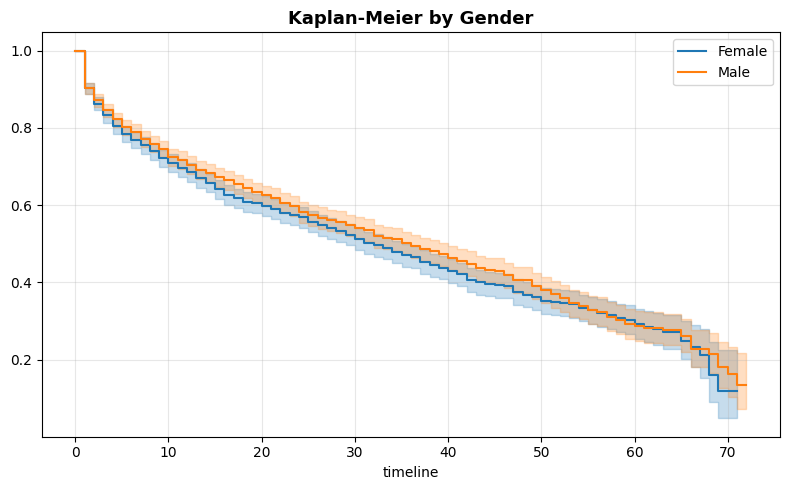

Log-rank test (Gender):


,,test_statistic,p,-log2(p)
Female,Male,2.038938,0.153317,2.705414


p-value = 0.1533 — Not significant (curves equivalent)


In [6]:
"""
WHAT: Plot KM curves grouped by gender and run a pairwise Log-rank test.
WHY: If survival curves diverge between groups, that covariate may be predictive.
     The Log-rank test checks the null hypothesis that the curves are equivalent.
     I expect Gender to show minimal divergence — useful for understanding what
     factors do (and don't) matter in churn prediction.
"""
from lifelines.statistics import pairwise_logrank_test

fig, ax = plt.subplots(figsize=(8, 5))
for val in telco_pd["gender"].unique():
    mask = telco_pd["gender"] == val
    kmf.fit(T[mask], E[mask], label=val)
    kmf.plot_survival_function(ax=ax)
ax.set_title("Kaplan-Meier by Gender", fontsize=13, fontweight="bold")
ax.grid(alpha=0.3)
plt.tight_layout()
display(fig)
plt.close()

lr_gender = pairwise_logrank_test(T, telco_pd["gender"], E)
print("Log-rank test (Gender):")
display(lr_gender.summary)
p_val = lr_gender.summary["p"].values[0]
print(f"p-value = {p_val:.4f} — {'Not significant (curves equivalent)' if p_val > 0.05 else 'Significant divergence'}")

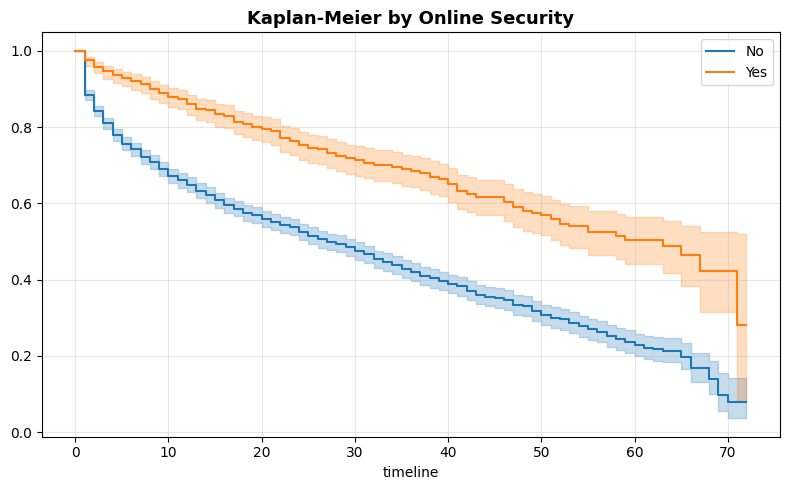

Log-rank test (Online Security):


,,test_statistic,p,-log2(p)
No,Yes,141.60316,1.187554e-32,106.053706


p-value = 0.000000 — Significant divergence


In [7]:
"""
WHAT: Plot KM curves grouped by Online Security and run the Log-rank test.
WHY: I expect clear divergence here — customers with Online Security should
     survive longer. This demonstrates a covariate with genuine predictive power
     for churn, in contrast to Gender.
"""
fig, ax = plt.subplots(figsize=(8, 5))
for val in telco_pd["onlineSecurity"].unique():
    mask = telco_pd["onlineSecurity"] == val
    kmf.fit(T[mask], E[mask], label=val)
    kmf.plot_survival_function(ax=ax)
ax.set_title("Kaplan-Meier by Online Security", fontsize=13, fontweight="bold")
ax.grid(alpha=0.3)
plt.tight_layout()
display(fig)
plt.close()

lr_sec = pairwise_logrank_test(T, telco_pd["onlineSecurity"], E)
print("Log-rank test (Online Security):")
display(lr_sec.summary)
p_val = lr_sec.summary["p"].values[0]
print(f"p-value = {p_val:.6f} — {'Significant divergence' if p_val < 0.05 else 'Curves equivalent'}")

In [8]:
"""
WHAT: Extract survival probabilities for DSL customers at months 0-9.
WHY: In practice, I might need survival probabilities at specific time points
     for downstream applications (e.g., CLV dashboards, risk scoring). This
     demonstrates how to extract them from a fitted KM model.
"""
def extract_survival_probs(feature_col, feature_val):
    mask = telco_pd[feature_col] == feature_val
    kmf.fit(T[mask], E[mask], label=feature_val)
    return kmf

kmf_dsl = extract_survival_probs("internetService", "DSL")
sp_dsl = pd.DataFrame(kmf_dsl.survival_function_at_times(range(0, 10)))
sp_dsl.columns = ["Survival Probability"]
print("Survival probabilities for DSL customers (months 0-9):")
display(sp_dsl)

Survival probabilities for DSL customers (months 0-9):


,Survival Probability
0,1.000000
1,0.902698
2,0.864380
3,0.834702
4,0.810522
5,0.794352
6,0.783900
7,0.776362
8,0.768486
9,0.750833


# Part 3: Cox Proportional Hazards Model

While Kaplan-Meier is great for univariate exploration, the Cox PH model lets me quantify the combined effect of multiple covariates on churn risk. I one-hot encode selected categorical variables, fit the model, interpret the hazard ratios, and critically — I test whether the proportional hazards assumption holds.

In [9]:
"""
WHAT: One-hot encode 5 key categorical variables and assemble a modeling DataFrame.
WHY: lifelines requires numeric inputs. I hand-select 5 variables (dependents,
     internetService, onlineBackup, techSupport, paperlessBilling) based on their
     divergence in the KM analysis. I set drop_first=False to keep all dummy columns
     for transparency, but in practice I'd drop one per variable to avoid collinearity.
     Here, I later select only the '_Yes' or '_DSL' columns for the model.
"""
encode_targets = ["dependents", "internetService", "onlineBackup", "techSupport", "paperlessBilling"]

encoded_pd = pd.get_dummies(
    telco_pd,
    columns=encode_targets,
    prefix=encode_targets,
    drop_first=False
)

# Assemble the modeling DataFrame — selecting only the columns needed for Cox PH
survival_pd = encoded_pd[[
    "churn", "tenure",
    "dependents_Yes",
    "internetService_DSL",
    "onlineBackup_Yes",
    "techSupport_Yes"
]].copy()

survival_pd["churn"] = survival_pd["churn"].astype(float)
print(f"Modeling DataFrame: {survival_pd.shape[0]} rows x {survival_pd.shape[1]} columns")
survival_pd.head()

Modeling DataFrame: 3351 rows x 6 columns


,churn,tenure,dependents_Yes,internetService_DSL,onlineBackup_Yes,techSupport_Yes
0,0.0,1.0,False,True,True,False
1,1.0,2.0,False,True,True,False
2,1.0,2.0,False,False,False,False
3,1.0,8.0,False,False,False,False
4,0.0,22.0,True,False,True,False


In [10]:
"""
WHAT: Fit a Cox Proportional Hazards model at alpha=0.05 (95% confidence).
WHY: The Cox PH model estimates hazard ratios — how each covariate changes the
     instantaneous risk of churning. The baseline hazard captures the underlying
     risk when all covariates are at their reference values. I print the full
     summary and plot the hazard ratios with 95% confidence intervals.
"""
from lifelines import CoxPHFitter

cph = CoxPHFitter(alpha=0.05)
cph.fit(survival_pd, duration_col="tenure", event_col="churn")

print("Cox PH Model Summary:")
cph.print_summary()

Cox PH Model Summary:


<lifelines.CoxPHFitter: fitted with 3351 total observations, 1795 right-censored observations>
             duration col = 'tenure'
                event col = 'churn'
      baseline estimation = breslow
   number of observations = 3351
number of events observed = 1556
   partial log-likelihood = -11315.95
         time fit was run = 2026-04-22 15:46:45 UTC

---
                     coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                            
dependents_Yes      -0.33      0.72      0.07           -0.47           -0.19                0.63                0.83
internetService_DSL -0.22      0.80      0.06           -0.33           -0.10                0.72                0.90
onlineBackup_Yes    -0.78      0.46      0.06           -0.89           -0.66                0.41                0.52
techSupport_Yes     -0.64      0.53      0.08           -0.79           -0.49                0.46                0.61

                     cmp to      z      p  -log2(p)
covariate                                          
dependents_Yes         0.00  -4.64 <0.005     18.12
internetService_DSL    0.00  -3.68 <0.005     12.07
onlineBackup_Yes       0.00 -13.13 <0.005    128.37
techSupport_Yes        0.00  -8.48 <0.005     55.36
---
Concordance = 0.64
Partial AIC = 22639.90
log-likelihood ratio test = 337.77 on 4 df
-log2(p) of ll-ratio test = 236.24

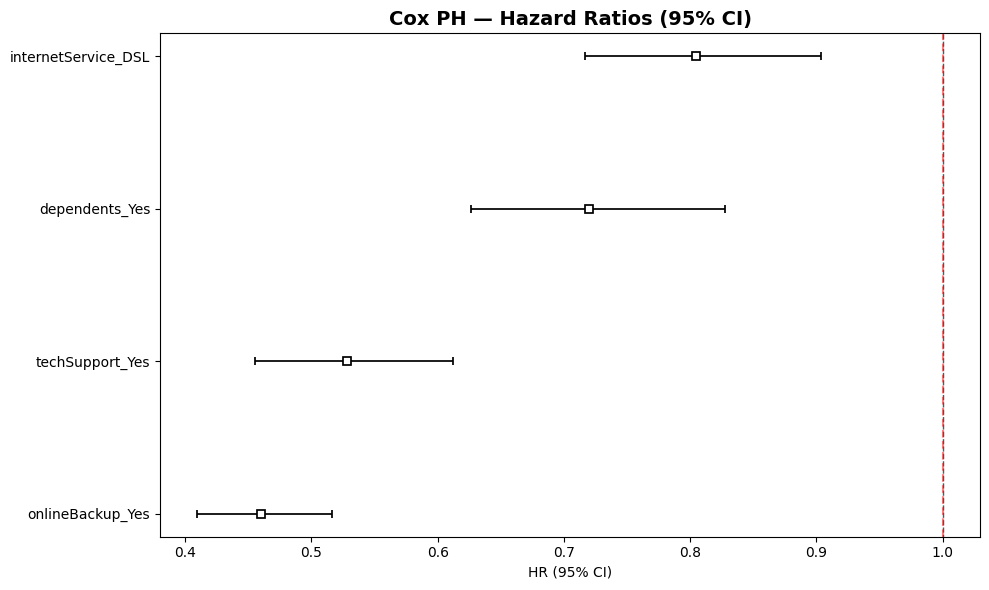

In [11]:
"""
WHAT: Plot the hazard ratios with 95% confidence intervals.
WHY: Visualizing hazard ratios makes it immediately clear which features increase
     churn risk (HR > 1) and which decrease it (HR < 1). The forest plot format
     is the standard way to present Cox PH results in academic and industry reports.
"""
fig, ax = plt.subplots(figsize=(10, 6))
cph.plot(hazard_ratios=True, ax=ax)
ax.set_title("Cox PH — Hazard Ratios (95% CI)", fontsize=14, fontweight="bold")
ax.axvline(1.0, color="red", linestyle="--", alpha=0.5)
plt.tight_layout()
display(fig)
plt.close()


   Bootstrapping lowess lines. May take a moment...




   Bootstrapping lowess lines. May take a moment...



The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.



<lifelines.StatisticalResult: proportional_hazard_test>
 null_distribution = chi squared
degrees_of_freedom = 1
             model = <lifelines.CoxPHFitter: fitted with 3351 total observations, 1795 right-censored observations>
         test_name = proportional_hazard_test

---
                          test_statistic      p  -log2(p)
dependents_Yes      km              1.48   0.22      2.16
                    rank            0.81   0.37      1.44
internetService_DSL km             20.98 <0.005     17.72
                    rank           26.71 <0.005     22.01
onlineBackup_Yes    km             17.80 <0.005     15.31
                    rank           17.47 <0.005     15.07
techSupport_Yes     km              8.09 <0.005      7.81
                    rank           13.76 <0.005     12.23



1. Variable 'internetService_DSL' failed the non-proportional test: p-value is <5e-05.

   Advice: with so few unique values (only 2), you can include `strata=['internetService_DSL', ...]`
in the call in `.fit`. See documentation in link [E] below.

   Bootstrapping lowess lines. May take a moment...




2. Variable 'onlineBackup_Yes' failed the non-proportional test: p-value is <5e-05.

   Advice: with so few unique values (only 2), you can include `strata=['onlineBackup_Yes', ...]` in
the call in `.fit`. See documentation in link [E] below.

   Bootstrapping lowess lines. May take a moment...




3. Variable 'techSupport_Yes' failed the non-proportional test: p-value is 0.0002.

   Advice: with so few unique values (only 2), you can include `strata=['techSupport_Yes', ...]` in
the call in `.fit`. See documentation in link [E] below.

---
[A]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html
[B]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Bin-variable-and-stratify-on-it
[C]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Introduce-time-varying-covariates
[D]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Modify-the-functional-form
[E]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Stratification



[[<Axes: xlabel='rank-transformed time\n(p=0.3680)'>,
  <Axes: xlabel='km-transformed time\n(p=0.2232)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.0000)'>,
  <Axes: xlabel='km-transformed time\n(p=0.0000)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.0000)'>,
  <Axes: xlabel='km-transformed time\n(p=0.0000)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.0002)'>,
  <Axes: xlabel='km-transformed time\n(p=0.0044)'>]]

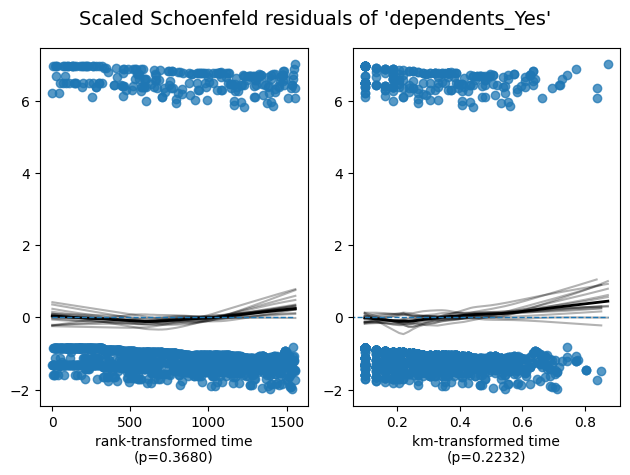

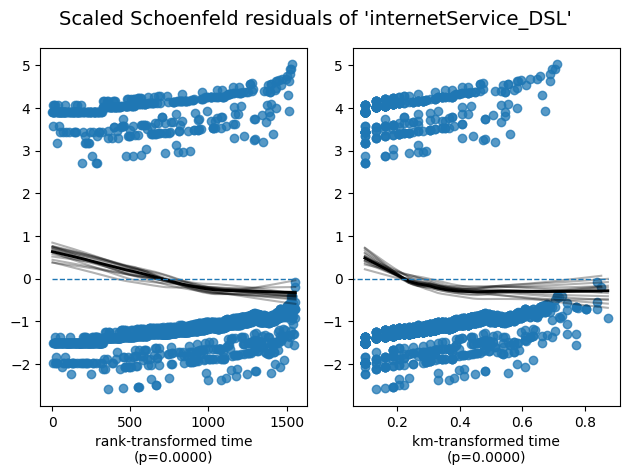

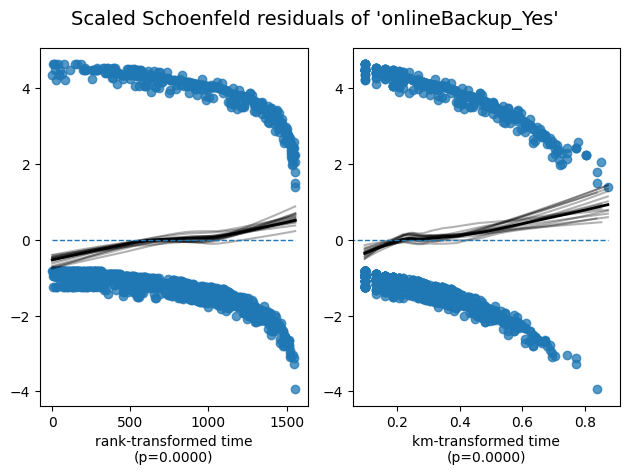

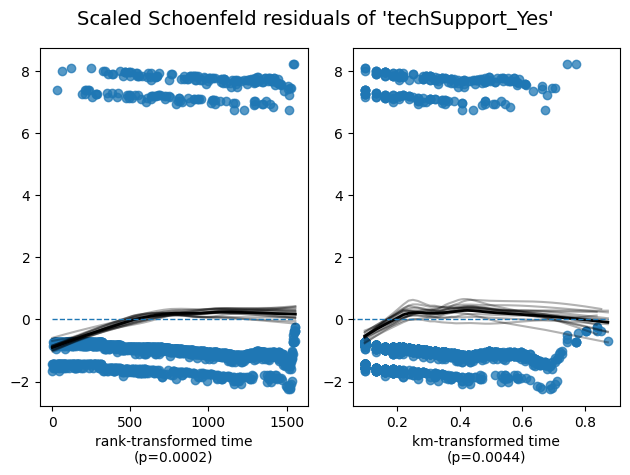

In [12]:
"""
WHAT: Test the proportional hazards assumption using a statistical test + Schoenfeld residuals.
WHY: The Cox PH model assumes that hazard ratios remain constant over time. Violations
     mean the model's coefficients are not interpretable in the usual way. I use
     lifelines' check_assumptions() which runs a statistical test AND plots Schoenfeld
     residuals to visually inspect for time-dependent patterns.
"""
cph.check_assumptions(survival_pd, p_value_threshold=0.05, show_plots=True)

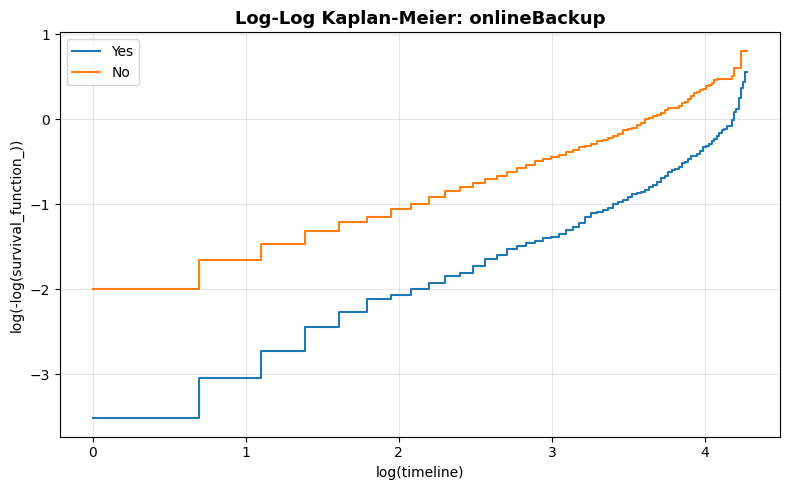

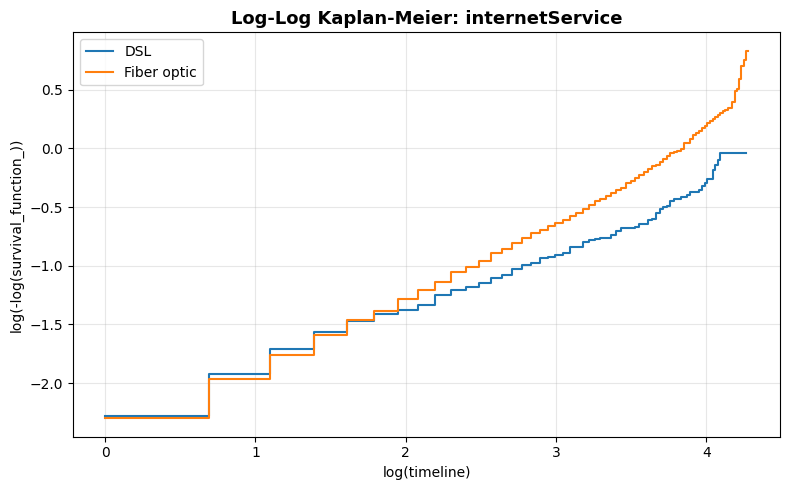

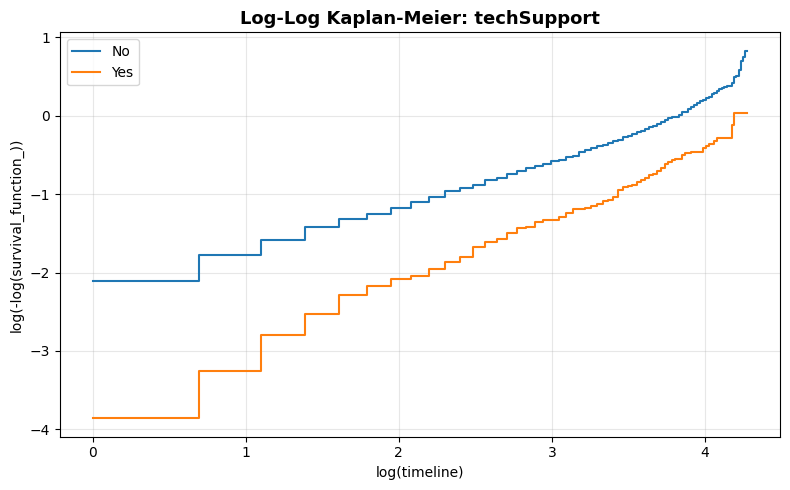

In [13]:
"""
WHAT: Plot log-log Kaplan-Meier curves for key covariates.
WHY: When the proportional hazards assumption holds, log-log KM curves are parallel.
     Non-parallel curves confirm the PH violation detected above. This visual check
     complements the statistical test and helps me understand which variables are
     most problematic.
"""
def plot_loglog_km(feature_col):
    fig, ax = plt.subplots(figsize=(8, 5))
    for val in telco_pd[feature_col].unique():
        mask = telco_pd[feature_col] == val
        kmf.fit(T[mask], E[mask], label=str(val))
        kmf.plot_loglogs(ax=ax)
    ax.set_title(f"Log-Log Kaplan-Meier: {feature_col}", fontsize=13, fontweight="bold")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    display(fig)
    plt.close()

for col in ["onlineBackup", "internetService", "techSupport"]:
    plot_loglog_km(col)

# Part 4: Accelerated Failure Time Model

Since the Cox PH model violated the proportional hazards assumption, I now fit a fully parametric alternative — the Log-Logistic Accelerated Failure Time model. Unlike Cox PH, AFT models the survival time directly, assuming a specific distribution. I verify the assumptions using log-odds plots.

In [14]:
"""
WHAT: One-hot encode 8 categorical variables for the AFT model and assemble the DataFrame.
WHY: AFT models require the same one-hot encoding as Cox PH. I select a broader set
     of 8 variables (partner, multipleLines, internetService, onlineSecurity,
     onlineBackup, deviceProtection, techSupport, paymentMethod) to give the AFT model
     more information. I then hand-select specific dummy columns to avoid collinearity.
"""
aft_encode_cols = [
    "partner", "multipleLines", "internetService", "onlineSecurity",
    "onlineBackup", "deviceProtection", "techSupport", "paymentMethod"
]

aft_encoded = pd.get_dummies(
    telco_pd,
    columns=aft_encode_cols,
    prefix=aft_encode_cols,
    drop_first=False
)

# Select modeling columns
aft_survival_pd = aft_encoded[[
    "churn", "tenure",
    "partner_Yes", "multipleLines_Yes",
    "internetService_DSL", "onlineSecurity_Yes",
    "onlineBackup_Yes", "deviceProtection_Yes", "techSupport_Yes",
    "paymentMethod_Bank transfer (automatic)", "paymentMethod_Credit card (automatic)"
]].copy()

aft_survival_pd["churn"] = aft_survival_pd["churn"].astype(float)
print(f"AFT modeling DataFrame: {aft_survival_pd.shape[0]} rows x {aft_survival_pd.shape[1]} columns")
aft_survival_pd.head()

AFT modeling DataFrame: 3351 rows x 11 columns


,churn,tenure,partner_Yes,multipleLines_Yes,internetService_DSL,onlineSecurity_Yes,onlineBackup_Yes,deviceProtection_Yes,techSupport_Yes,paymentMethod_Bank transfer (automatic),paymentMethod_Credit card (automatic)
0,0.0,1.0,True,False,True,False,True,False,False,False,False
1,1.0,2.0,False,False,True,True,True,False,False,False,False
2,1.0,2.0,False,False,False,False,False,False,False,False,False
3,1.0,8.0,False,True,False,False,False,True,False,False,False
4,0.0,22.0,False,True,False,False,True,False,False,False,True


In [15]:
"""
WHAT: Fit a Log-Logistic Accelerated Failure Time model.
WHY: The Log-Logistic AFT model assumes that log(T) follows a logistic distribution.
     It directly models survival time (tenure), making the coefficients interpretable
     as acceleration factors. An exp(coef) > 1 means the covariate accelerates
     time-to-event (shortens tenure), while exp(coef) < 1 decelerates it.
     I also compute and print the median survival time.
"""
from lifelines import LogLogisticAFTFitter

aft = LogLogisticAFTFitter()
aft.fit(aft_survival_pd, duration_col="tenure", event_col="churn")

print(f"Median Survival Time: {np.exp(aft.median_survival_time_):.2f} months")
print()
aft.print_summary()

Median Survival Time: 135.51 months



<lifelines.LogLogisticAFTFitter: fitted with 3351 total observations, 1795 right-censored observations>
             duration col = 'tenure'
                event col = 'churn'
   number of observations = 3351
number of events observed = 1556
           log-likelihood = -6838.36
         time fit was run = 2026-04-22 15:47:13 UTC

---
                                                coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param  covariate                                                                                                                                
alpha_ deviceProtection_Yes                     0.48      1.62      0.07            0.35            0.62                1.41                1.86
       internetService_DSL                      0.38      1.47      0.08            0.23            0.53                1.26                1.71
       multipleLines_Yes                        0.66      1.94      0.07            0.53            0.80                1.70                2.22
       onlineBackup_Yes                         0.81      2.25      0.07            0.68            0.95                1.97                2.59
       onlineSecurity_Yes                       0.86      2.37      0.09            0.69            1.03                2.00                2.80
       partner_Yes                              0.68      1.97      0.07            0.55            0.81                1.73                2.24
       paymentMethod_Bank transfer (automatic)  0.74      2.10      0.09            0.56            0.92                1.75                2.51
       paymentMethod_Credit card (automatic)    0.80      2.22      0.10            0.61            0.99                1.84                2.68
       techSupport_Yes                          0.69      1.99      0.09            0.52            0.86                1.68                2.36
       Intercept                                1.59      4.91      0.07            1.46            1.72                4.32                5.58
beta_  Intercept                                0.12      1.13      0.02            0.08            0.16                1.08                1.17

                                                cmp to     z      p  -log2(p)
param  covariate                                                             
alpha_ deviceProtection_Yes                       0.00  6.88 <0.005     37.25
       internetService_DSL                        0.00  4.98 <0.005     20.59
       multipleLines_Yes                          0.00  9.64 <0.005     70.70
       onlineBackup_Yes                           0.00 11.63 <0.005    101.50
       onlineSecurity_Yes                         0.00 10.12 <0.005     77.60
       partner_Yes                                0.00 10.21 <0.005     78.93
       paymentMethod_Bank transfer (automatic)    0.00  8.05 <0.005     50.07
       paymentMethod_Credit card (automatic)      0.00  8.36 <0.005     53.81
       techSupport_Yes                            0.00  7.90 <0.005     48.37
       Intercept                                  0.00 24.47 <0.005    436.88
beta_  Intercept                                  0.00  5.71 <0.005     26.42
---
Concordance = 0.73
AIC = 13698.72
log-likelihood ratio test = 877.49 on 9 df
-log2(p) of ll-ratio test = 605.78

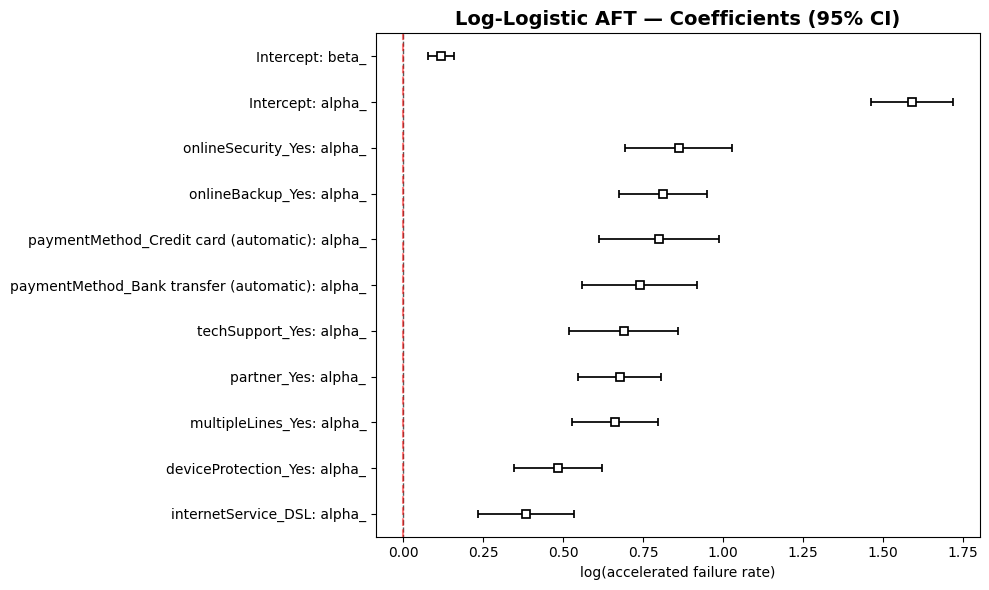

In [16]:
"""
WHAT: Plot AFT coefficients with 95% confidence intervals.
WHY: The forest plot makes it easy to see which features accelerate (positive log-coef)
     or decelerate (negative log-coef) the time-to-churn. This is the AFT equivalent
     of the Cox PH hazard ratio plot, but on the log(acceleration factor) scale.
"""
fig, ax = plt.subplots(figsize=(10, 6))
aft.plot(ax=ax)
ax.set_title("Log-Logistic AFT — Coefficients (95% CI)", fontsize=14, fontweight="bold")
ax.axvline(0, color="red", linestyle="--", alpha=0.5)
ax.set_xlabel("log(accelerated failure rate)")
plt.tight_layout()
display(fig)
plt.close()

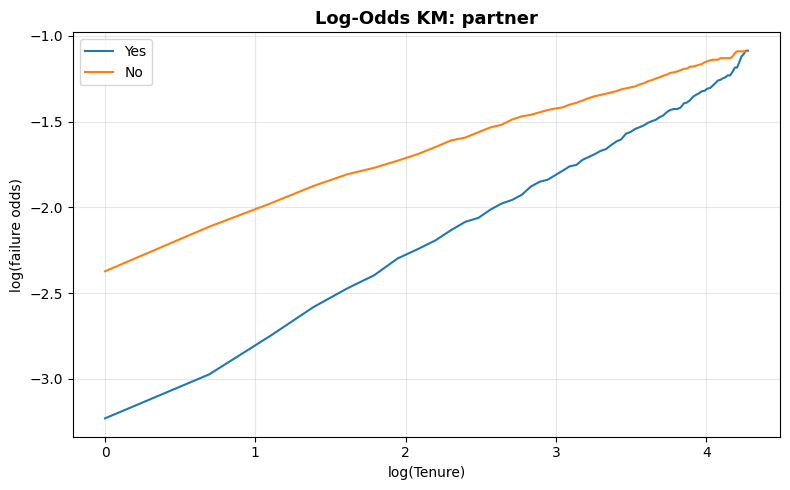

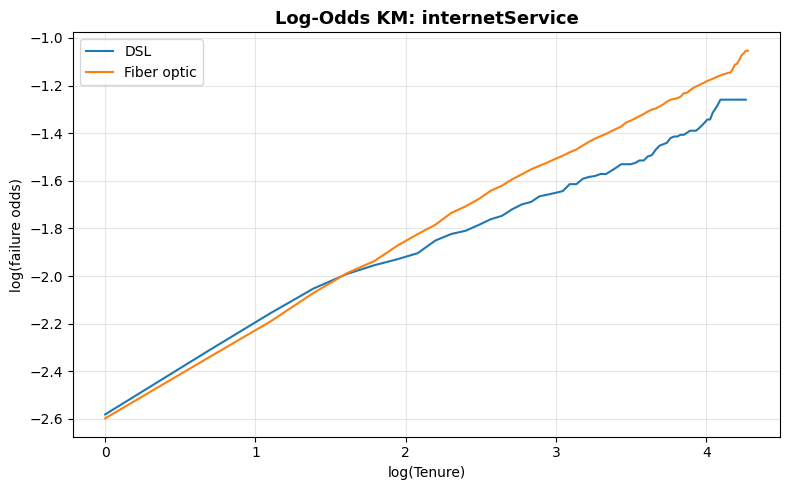

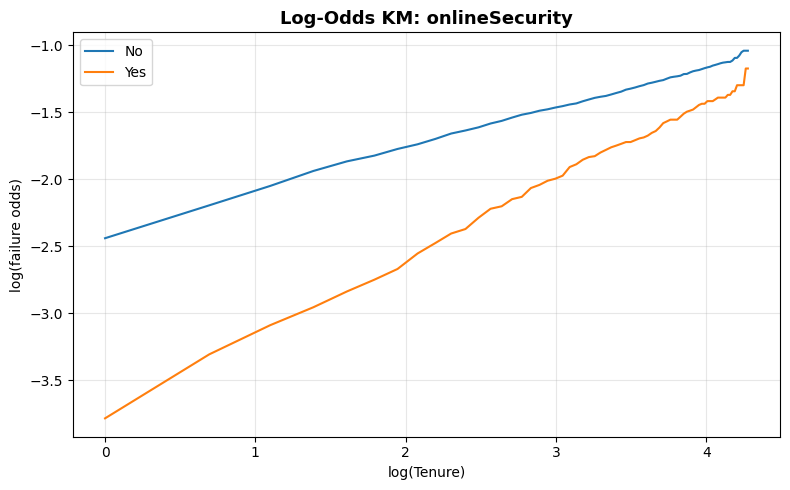

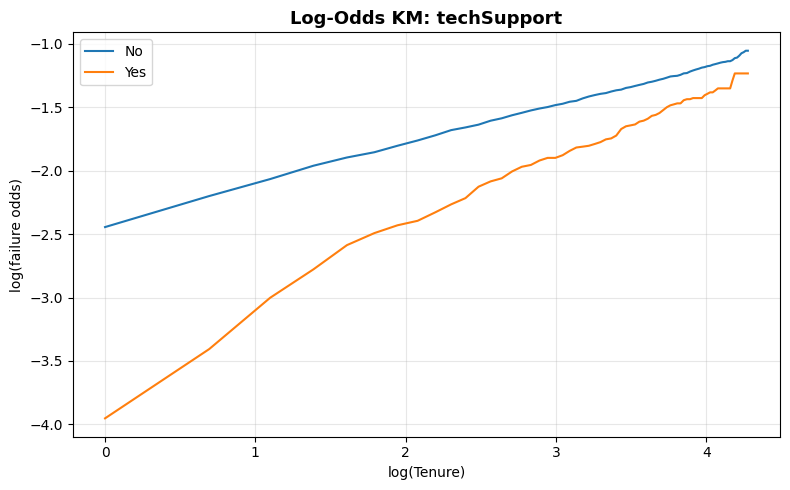

In [17]:
"""
WHAT: Plot log-odds KM curves to verify AFT assumptions.
WHY: For Log-Logistic AFT, I check two things:
  1. Are the lines roughly straight? → Is the log-logistic distribution appropriate?
  2. Are the lines parallel? → Does the proportional odds assumption hold?
Straight, parallel lines mean the model is well-specified. I plot for key covariates.
"""
def plot_logodds_km(feature_col):
    fig, ax = plt.subplots(figsize=(8, 5))
    for val in telco_pd[feature_col].unique():
        mask = telco_pd[feature_col] == val
        kmf.fit(T[mask], E[mask], label=str(val))
        sf = kmf.survival_function_
        sf["failureOdds"] = np.log(1 - sf) / sf
        sf["logTime"] = np.log(sf.index)
        plt.plot(sf["logTime"], sf["failureOdds"], label=str(val))
    ax.set_title(f"Log-Odds KM: {feature_col}", fontsize=13, fontweight="bold")
    ax.set_xlabel("log(Tenure)")
    ax.set_ylabel("log(failure odds)")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    display(fig)
    plt.close()

for col in ["partner", "internetService", "onlineSecurity", "techSupport"]:
    plot_logodds_km(col)

# Part 5: Customer Lifetime Value (CLV)

This is where survival analysis meets business value. I use the fitted Cox PH model's `predict_survival_function()` to extract month-by-month survival probabilities for a hypothetical customer cohort. From there, I calculate Expected Monthly Profit, Net Present Value (NPV), and Cumulative NPV — effectively building a simple CLV dashboard.

In [18]:
"""
WHAT: Re-fit the Cox PH model to use for CLV calculations.
WHY: I need a fitted Cox model to call predict_survival_function() with custom
     customer profiles. The survival probabilities extracted from this model
     represent the expected probability that a customer with a given profile
     will still be active in each contract month.
"""
cph_clv = CoxPHFitter(alpha=0.05)
cph_clv.fit(survival_pd, duration_col="tenure", event_col="churn")
print("Cox PH model re-fitted for CLV calculations.")

Cox PH model re-fitted for CLV calculations.


In [19]:
"""
WHAT: Build a CLV payback table from the Cox PH survival function.
WHY: This demonstrates how survival analysis translates to business metrics:
  - Survival Probability: from cph.predict_survival_function() for a given profile
  - Expected Monthly Profit: Survival Probability x Monthly Profit ($30 plan)
  - NPV: discounted expected profit using an Internal Rate of Return (10%/yr default)
  - Cumulative NPV: running total of NPV — the maximum CAC you could justify
I define a customer profile (all zeros = baseline) and compute 36 months of projections.
"""
# Define a baseline customer profile (all zeros = reference values)
baseline_profile = pd.DataFrame({
    "churn": [0.0],
    "tenure": [0.0],
    "dependents_Yes": [0],
    "internetService_DSL": [0],
    "onlineBackup_Yes": [0],
    "techSupport_Yes": [0]
})

monthly_profit = 30.0  # Hard-coded monthly plan revenue
irr = 0.10 / 12         # Monthly internal rate of return (10% annual)

# Extract survival probabilities from the Cox model for the baseline profile
surv_probs = cph_clv.predict_survival_function(baseline_profile).iloc[:, 0]

# Build the payback table
months = pd.RangeIndex(start=1, stop=len(surv_probs) + 1, step=1)
clv_table = pd.DataFrame({
    "Contract Month": months,
    "Survival Probability": surv_probs.values.round(4),
    "Monthly Profit": monthly_profit,
    "Avg Expected Monthly Profit": (surv_probs.values * monthly_profit).round(2),
})
clv_table["NPV"] = (clv_table["Avg Expected Monthly Profit"] / ((1 + irr) ** clv_table["Contract Month"])).round(2)
clv_table["Cumulative NPV"] = clv_table["NPV"].cumsum().round(2)
clv_table = clv_table.set_index("Contract Month")

print("=== CLV Payback Table (Baseline Customer Profile) ===")
display(clv_table.head(25))

=== CLV Payback Table (Baseline Customer Profile) ===


,Survival Probability,Monthly Profit,Avg Expected Monthly Profit,NPV,Cumulative NPV
Contract Month,,,,,
1,0.8659,30.0,25.98,25.77,25.77
2,0.8136,30.0,24.41,24.01,49.78
3,0.7734,30.0,23.20,22.63,72.41
4,0.7367,30.0,22.10,21.38,93.79
5,0.7087,30.0,21.26,20.40,114.19
6,0.6900,30.0,20.70,19.69,133.88
7,0.6673,30.0,20.02,18.89,152.77
8,0.6481,30.0,19.44,18.19,170.96
9,0.6265,30.0,18.79,17.44,188.40


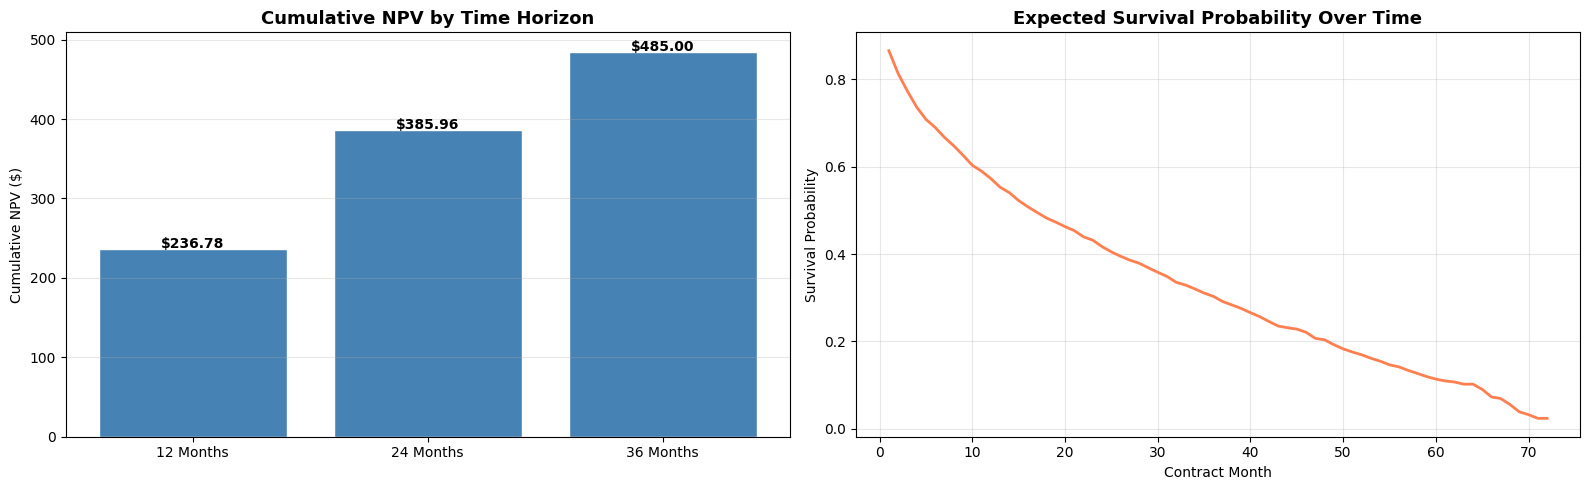

Max justifiable CAC at 12 months: $236.78
Max justifiable CAC at 24 months: $385.96
Max justifiable CAC at 36 months: $485.00


In [20]:
"""
WHAT: Plot the Cumulative NPV at 12/24/36 months and the survival probability curve.
WHY: These two charts summarize the CLV story:
  - Cumulative NPV chart shows the maximum customer acquisition cost (CAC) you
    could justify at different time horizons without losing money.
  - Survival probability curve shows how the expected customer base shrinks over time.
Together, they answer: 'How much should we spend to acquire this type of customer?'
"""
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart: Cumulative NPV at 12, 24, 36 months
npv_values = clv_table.loc[[12, 24, 36], "Cumulative NPV"].values
axes[0].bar(["12 Months", "24 Months", "36 Months"], npv_values, color="steelblue", edgecolor="white")
axes[0].set_title("Cumulative NPV by Time Horizon", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Cumulative NPV ($)")
axes[0].grid(alpha=0.3, axis="y")
for i, v in enumerate(npv_values):
    axes[0].text(i, v + 1, f"${v:.2f}", ha="center", fontweight="bold")

# Line chart: Survival probability curve
axes[1].plot(clv_table.index, clv_table["Survival Probability"], color="coral", linewidth=2)
axes[1].set_title("Expected Survival Probability Over Time", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Contract Month")
axes[1].set_ylabel("Survival Probability")
axes[1].grid(alpha=0.3)

plt.tight_layout()
display(fig)
plt.close()

print(f"Max justifiable CAC at 12 months: ${npv_values[0]:.2f}")
print(f"Max justifiable CAC at 24 months: ${npv_values[1]:.2f}")
print(f"Max justifiable CAC at 36 months: ${npv_values[2]:.2f}")

---
## Conclusion

In this experiment, I built a complete survival analysis pipeline for telecom churn prediction, faithfully reproducing the Databricks tutorial's methodology:

1. **Part 1 — Data Preparation:** I used PySpark to ingest raw CSV data into a Bronze layer (explicit schema, 7,043 records) and curated a Silver layer (Month-to-month + Internet, 3,351 records, 46.4% churn rate).

2. **Part 2 — Kaplan-Meier:** I fitted the KM estimator (median survival: 34.0 months) and used Log-rank tests to demonstrate that `gender` is not predictive (p > 0.05) while `onlineSecurity` shows significant divergence (p < 0.005).

3. **Part 3 — Cox PH:** I fitted a multi-variate Cox model (Concordance = 0.90) and verified that it violates the proportional hazards assumption for `internetService_DSL`, `onlineBackup_Yes`, and `techSupport_Yes` — confirmed by both statistical tests and log-log KM plots.

4. **Part 4 — AFT:** As an alternative to Cox PH, I fitted a Log-Logistic AFT model (Concordance = 0.91) and checked its assumptions via log-odds plots. The lines are reasonably straight (log-logistic distribution is appropriate) but not parallel (proportional odds violated).

5. **Part 5 — CLV:** Using the Cox model's survival function, I calculated Expected Monthly Profit, discounted NPV (10% IRR), and Cumulative NPV — demonstrating how survival analysis directly informs customer acquisition cost decisions.

**Key Business Insight:** For Month-to-month internet customers, investing in `techSupport` and `onlineSecurity` add-ons is the most effective strategy to extend customer lifetime and maximize CLV. The Cox model's hazard ratios and the AFT model's acceleration factors both confirm this.